# Reproducing Zhang et al.: adaptive transfer on DSA (PyHealth)

This notebook follows the **AAAI reproducibility proposal** for *Daily Physical Activity Monitoring: Adaptive Learning from Multi-Source Motion Sensor Data*: shared setup (**§0**), **paper-aligned baselines** (**§1**), **controlled ablations** (**§2**), and **distance-function extensions** for embedding-based IPD (**§3**).

**Stack:** PyHealth `AdaptiveTransferModel` + `Trainer`, **PyTorch** only (no TensorFlow/Keras). **DTW–IPD** uses NumPy multivariate DTW and optional scikit-learn `KernelDensity`, matching the public `HealthTimeSerial` logic.

**Environment:** activate the project venv, install the library (`pip install -e .`), and add `jupyter` / `matplotlib` if needed. Register the venv as a Jupyter kernel if you want the **PyHealth (.venv)** interpreter.


## 0) Common functions and variables

The cells below define **all** hyper-parameters (including epoch budgets), helpers, and shared data objects (`bundles`, validation indices, optional **probe** for embedding IPD, and **ranked source order**). Every later experiment calls the same `run_experiment` routine with a small `TrainConfig` delta so variability stays controlled.


In [1]:
from __future__ import annotations

import os
import random
import sys
import warnings
from dataclasses import dataclass
from itertools import chain
from pathlib import Path
from typing import Callable, Dict, List, Optional, Sequence, Tuple, Union

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.spatial.distance as spd
import torch
import torch.nn.functional as F
from sklearn.neighbors import KernelDensity

warnings.filterwarnings("ignore", category=UserWarning)

_CWD = Path.cwd().resolve()
if (_CWD / "pyhealth").is_dir():
    REPO_ROOT = _CWD
elif (_CWD.parent / "pyhealth").is_dir():
    REPO_ROOT = _CWD.parent
else:
    raise FileNotFoundError("Run from the PyHealth repo root or from examples/.")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from pyhealth.datasets import DSADataset, create_sample_dataset, get_dataloader
from pyhealth.datasets.utils import collate_fn_dict_with_padding
from pyhealth.metrics import multiclass_metrics_fn
from pyhealth.models.adaptive_transfer import AdaptiveTransferModel
from pyhealth.tasks import DSAActivityClassification
from pyhealth.trainer import Trainer

plt.rcParams.update(
    {"figure.figsize": (8, 4), "axes.grid": True, "grid.alpha": 0.3}
)

print("Python:", sys.executable)
print("Repo root:", REPO_ROOT)


/Users/tomiyoshi/DataspellProjects/PyHealth/.venv-test/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Python: /Users/tomiyoshi/DataspellProjects/PyHealth/.venv-test/bin/python
Repo root: /Users/tomiyoshi/DataspellProjects/PyHealth


In [2]:
# --- Shared hyper-parameters (single source of truth for epoch budgets) ---
DSA_ROOT = Path(os.environ.get("DSA_ROOT", REPO_ROOT / "HealthTimeSerial" / "data")).resolve()
TARGET_UNIT = "LL"
ALL_UNITS = ("T", "RA", "LA", "RL", "LL")
SOURCE_UNITS = tuple(u for u in ALL_UNITS if u != TARGET_UNIT)

SEED = 598
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
BATCH_SIZE = 64
HIDDEN_DIM = 64
NUM_LAYERS = 1
DROPOUT = 0.2

EPOCHS_PROBE = 2
EPOCHS_PRETRAIN_PER_SOURCE = 2
EPOCHS_FINETUNE = 8

# INFORMS-style binary runs reuse the same per-phase budgets
EPOCHS_PRETRAIN_INFORMS = EPOCHS_PRETRAIN_PER_SOURCE
EPOCHS_FINETUNE_INFORMS = EPOCHS_FINETUNE

BINARY_REPS = 5
BINARY_BATCH = 16
MAX_IPD_TRAIN_SAMPLES = 350
PROBE_EMBEDDING_EPOCHS = 1

INFORMS_TRAIN_SUBJECTS = 6

# IPD geometry for off-model DTW: "dtw" (NumPy) or "embedding" (probe.compute_ipd)
IPD_METRIC = "dtw"

IPD_USE_PAPER_KDE = True
IPD_KDE_BANDWIDTH = 7.8
IPD_KDE_DRAWS = 10
IPD_KDE_RANDOM_STATE = 0
IPD_USE_GAUSSIAN_NOISE = True
IPD_KDE_NOISE_STD = 0.01

RUN_FULL_ABLATION_GRID = False

if not DSA_ROOT.is_dir():
    raise FileNotFoundError(
        f"DSA_ROOT not found: {DSA_ROOT}\n"
        "Download UCI DSA under this path or set DSA_ROOT."
    )

print("DSA_ROOT:", DSA_ROOT)
print("TARGET_UNIT:", TARGET_UNIT, "| SOURCES:", SOURCE_UNITS)
print(
    "Epochs — probe / pretrain-per-source / finetune:",
    EPOCHS_PROBE,
    EPOCHS_PRETRAIN_PER_SOURCE,
    EPOCHS_FINETUNE,
)
print("DEVICE:", DEVICE)


DSA_ROOT: /Users/tomiyoshi/DataspellProjects/PyHealth/HealthTimeSerial/data
TARGET_UNIT: LL | SOURCES: ('T', 'RA', 'LA', 'RL')
Epochs — probe / pretrain-per-source / finetune: 2 2 8
DEVICE: mps


In [21]:
# --- Splits, loaders, DTW-IPD, training utilities ---


def patient_split_indices(
    dataset,
    ratios: Tuple[float, float, float] = (0.5, 0.25, 0.25),
    seed: int = SEED,
) -> Dict[str, List[int]]:
    rng = np.random.default_rng(seed)
    patient_ids = list(dataset.patient_to_index.keys())
    rng.shuffle(patient_ids)
    n = len(patient_ids)
    n_train = int(n * ratios[0])
    n_val = int(n * ratios[1])
    train_p = patient_ids[:n_train]
    val_p = patient_ids[n_train : n_train + n_val]
    test_p = patient_ids[n_train + n_val :]

    def expand(patients):
        return list(chain(*[dataset.patient_to_index[pid] for pid in patients]))

    return {
        "train": expand(train_p),
        "val": expand(val_p),
        "test": expand(test_p),
        "train_patients": train_p,
        "val_patients": val_p,
        "test_patients": test_p,
    }


def subset_dataset(ds, indices: Sequence[int]):
    return ds.subset(list(indices))


@dataclass
class DomainBundle:
    unit: str
    full: object
    train: object
    val: object
    test: object


def build_domain_datasets(
    base: DSADataset,
    root: Path,
    units: Sequence[str],
    split: Dict[str, List[int]],
    num_workers: int = 1,
) -> Dict[str, DomainBundle]:
    out: Dict[str, DomainBundle] = {}
    for u in units:
        task = DSAActivityClassification(
            dataset_root=str(root),
            selected_units=(u,),
        )
        full = base.set_task(task, num_workers=num_workers)
        out[u] = DomainBundle(
            unit=u,
            full=full,
            train=subset_dataset(full, split["train"]),
            val=subset_dataset(full, split["val"]),
            test=subset_dataset(full, split["test"]),
        )
    return out


def make_loaders(train_ds, val_ds, test_ds, batch_size: int = BATCH_SIZE):
    train_loader = get_dataloader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = get_dataloader(val_ds, batch_size=batch_size, shuffle=False)
    test_loader = get_dataloader(test_ds, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader, test_loader


def collate_indices(ds, indices: Sequence[int], batch_size: int) -> List[Dict]:
    out = []
    for i in range(0, len(indices), batch_size):
        chunk = indices[i : i + batch_size]
        rows = [ds[j] for j in chunk]
        out.append(collate_fn_dict_with_padding(rows))
    return out


def _signals_numpy_from_batch(batch: Dict, key: str = "signal") -> np.ndarray:
    sig = batch[key]
    if isinstance(sig, tuple):
        sig = sig[0]
    if hasattr(sig, "detach"):
        arr = sig.detach().cpu().float().numpy()
    else:
        arr = np.asarray(sig, dtype=np.float64)
    if arr.ndim == 2:
        arr = arr[:, :, np.newaxis]
    return arr


def multivariate_dtw_numpy(x: np.ndarray, y: np.ndarray) -> float:
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    if x.ndim != 2 or y.ndim != 2 or x.shape[1] != y.shape[1]:
        raise ValueError(f"Expected (T1, D) and (T2, D); got {x.shape}, {y.shape}")
    diff = x[:, None, :] - y[None, :, :]
    cost = np.sum(diff * diff, axis=2)
    n, m = cost.shape
    acc = np.full((n + 1, m + 1), np.inf, dtype=np.float64)
    acc[0, 0] = 0.0
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            acc[i, j] = cost[i - 1, j - 1] + min(
                acc[i - 1, j], acc[i, j - 1], acc[i - 1, j - 1]
            )
    return float(np.sqrt(acc[n, m]))


def paired_multivariate_dtw_distances(
    ba: Dict, bb: Dict, feature_key: str = "signal"
) -> np.ndarray:
    xs = _signals_numpy_from_batch(ba, feature_key)
    ys = _signals_numpy_from_batch(bb, feature_key)
    if xs.shape[0] != ys.shape[0]:
        raise ValueError("Paired IPD requires matching batch sizes.")
    out = np.empty(xs.shape[0], dtype=np.float64)
    for i in range(xs.shape[0]):
        out[i] = multivariate_dtw_numpy(xs[i], ys[i])
    return out


def paper_kde_sample_mean(
    distances: np.ndarray,
    bandwidth: float = 7.8,
    n_draws: int = 10,
    random_state: int = 0,
) -> float:
    d = np.asarray(distances, dtype=np.float64).reshape(-1, 1)
    if d.shape[0] == 0:
        return 0.0
    kde = KernelDensity(kernel="gaussian", bandwidth=bandwidth).fit(d)
    samples = kde.sample(n_draws, random_state=random_state)
    return float(np.mean(samples))


def summarize_ipd_distances(
    distances: np.ndarray,
    *,
    use_paper_kde: bool = False,
    kde_bandwidth: float = 7.8,
    kde_n_draws: int = 10,
    kde_random_state: Optional[int] = None,
    use_gaussian_noise: bool = False,
    noise_std: float = 0.01,
    rng: Optional[np.random.Generator] = None,
) -> float:
    d = np.asarray(distances, dtype=np.float64).ravel()
    if d.size == 0:
        return 0.0
    if use_paper_kde:
        return paper_kde_sample_mean(
            d,
            bandwidth=kde_bandwidth,
            n_draws=kde_n_draws,
            random_state=0 if kde_random_state is None else int(kde_random_state),
        )
    if use_gaussian_noise:
        rng = rng or np.random.default_rng()
        d = np.maximum(d + rng.normal(0.0, noise_std, size=d.shape), 0.0)
    return float(np.mean(d))


def dtw_ipd_from_dataset_batches(
    batches_src: Sequence[Dict],
    batches_tgt: Sequence[Dict],
    *,
    use_paper_kde: bool = False,
    kde_bandwidth: float = 7.8,
    kde_n_draws: int = 10,
    kde_random_state: Optional[int] = None,
    use_gaussian_noise: bool = False,
    noise_std: float = 0.01,
    rng: Optional[np.random.Generator] = None,
    feature_key: str = "signal",
) -> float:
    all_d: List[float] = []
    for a, b in zip(batches_src, batches_tgt):
        all_d.extend(
            paired_multivariate_dtw_distances(a, b, feature_key=feature_key).tolist()
        )
    return summarize_ipd_distances(
        np.array(all_d, dtype=np.float64),
        use_paper_kde=use_paper_kde,
        kde_bandwidth=kde_bandwidth,
        kde_n_draws=kde_n_draws,
        kde_random_state=kde_random_state,
        use_gaussian_noise=use_gaussian_noise,
        noise_std=noise_std,
        rng=rng,
    )


def mean_ipd_between(
    model: Optional[AdaptiveTransferModel],
    ds_src,
    ds_tgt,
    val_indices: Sequence[int],
    batch_size: int = 64,
    *,
    use_paper_kde: Optional[bool] = None,
    rng: Optional[np.random.Generator] = None,
) -> float:
    use_pk = IPD_USE_PAPER_KDE if use_paper_kde is None else bool(use_paper_kde)
    if IPD_METRIC == "embedding":
        if model is None:
            raise ValueError("IPD_METRIC='embedding' requires a probe model.")
        model.eval()
    batches_src = collate_indices(ds_src, val_indices, batch_size)
    batches_tgt = collate_indices(ds_tgt, val_indices, batch_size)
    if IPD_METRIC == "embedding":
        vals: List[float] = []
        for a, b in zip(batches_src, batches_tgt):
            vals.append(model.compute_ipd(a, b))
        return float(np.mean(vals))
    if IPD_METRIC == "dtw":
        return dtw_ipd_from_dataset_batches(
            batches_src,
            batches_tgt,
            use_paper_kde=use_pk,
            kde_bandwidth=IPD_KDE_BANDWIDTH,
            kde_n_draws=IPD_KDE_DRAWS,
            kde_random_state=IPD_KDE_RANDOM_STATE,
            use_gaussian_noise=(not use_pk and IPD_USE_GAUSSIAN_NOISE),
            noise_std=IPD_KDE_NOISE_STD,
            rng=rng,
        )
    raise ValueError(f"Unknown IPD_METRIC: {IPD_METRIC}")


def ipd_similarity_matrix(
    probe_model: Optional[AdaptiveTransferModel],
    bundles_map: Dict[str, DomainBundle],
    units: Sequence[str],
    val_indices: Sequence[int],
) -> np.ndarray:
    n = len(units)
    mat = np.zeros((n, n), dtype=np.float64)
    for i, ui in enumerate(units):
        for j, uj in enumerate(units):
            if i == j:
                mat[i, j] = 0.0
            else:
                mat[i, j] = mean_ipd_between(
                    probe_model,
                    bundles_map[ui].full,
                    bundles_map[uj].full,
                    val_indices,
                )
    return mat


def ranked_sources_ipd(
    probe_model: Optional[AdaptiveTransferModel],
    bundles_map: Dict[str, DomainBundle],
    val_indices: Sequence[int],
    *,
    use_paper_kde: Optional[bool] = None,
) -> Tuple[List[str], Dict[str, float]]:
    src_to_tgt = {
        s: mean_ipd_between(
            probe_model,
            bundles_map[s].full,
            bundles_map[TARGET_UNIT].full,
            val_indices,
            use_paper_kde=use_paper_kde,
        )
        for s in SOURCE_UNITS
    }
    order = sorted(SOURCE_UNITS, key=lambda u: src_to_tgt[u])
    return order, src_to_tgt


def train_with_trainer(
    model: AdaptiveTransferModel,
    train_loader,
    val_loader,
    epochs: int,
    lr: float,
    monitor: Optional[str] = "accuracy",
) -> None:
    trainer = Trainer(
        model=model,
        device=DEVICE,
        metrics=["accuracy"],
        enable_logging=False,
    )
    trainer.train(
        train_dataloader=train_loader,
        val_dataloader=val_loader,
        epochs=epochs,
        optimizer_params={"lr": lr},
        monitor=monitor,
        load_best_model_at_last=False,
    )


def evaluate_accuracy(model: AdaptiveTransferModel, test_loader) -> float:
    trainer = Trainer(
        model=model,
        device=DEVICE,
        metrics=["accuracy"],
        enable_logging=False,
    )
    scores = trainer.evaluate(test_loader)
    return float(scores["accuracy"])


def add_gaussian_noise(batch: dict, std: float) -> dict:
    if std <= 0:
        return batch
    out = dict(batch)
    sig = out["signal"]
    if isinstance(sig, torch.Tensor):
        out["signal"] = sig + torch.randn_like(sig) * std
    return out


def accuracy_under_noise(
    model: AdaptiveTransferModel, test_loader, noise_stds: Sequence[float]
) -> List[float]:
    model.eval()
    results = []
    for std in noise_stds:
        ys, ps = [], []
        for data in test_loader:
            data = {
                k: (v.to(DEVICE) if isinstance(v, torch.Tensor) else v)
                for k, v in data.items()
            }
            data = add_gaussian_noise(data, std)
            with torch.no_grad():
                out = model(**data)
            ys.append(out["y_true"].cpu().numpy())
            ps.append(out["y_prob"].cpu().numpy())
        y = np.concatenate(ys)
        p = np.concatenate(ps)
        scores = multiclass_metrics_fn(y, p, metrics=["accuracy"])
        results.append(float(scores["accuracy"]))
    return results


def kulczynski_pairwise(x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
    xn = x.detach().float().cpu().numpy()
    yn = y.detach().float().cpu().numpy()
    out = np.empty(x.shape[0], dtype=np.float64)
    for i in range(x.shape[0]):
        a = xn[i] >= np.median(xn[i])
        b = yn[i] >= np.median(yn[i])
        jac = spd.jaccard(a, b)
        out[i] = float(1 / (1 - jac) - 1 if jac < 1 else float('inf'))
    return torch.as_tensor(out, device=x.device, dtype=x.dtype)


# --- INFORMS binary helpers (paper RCC task) ---


def informs_subject_split(
    all_subjects: Sequence[str],
    n_train: int,
    seed: int,
) -> Tuple[set, set]:
    rng = np.random.default_rng(seed)
    ids = list(all_subjects)
    rng.shuffle(ids)
    train_s = set(ids[:n_train])
    val_s = set(ids[n_train:])
    return train_s, val_s


def samples_for_subjects(
    sample_ds,
    subjects: set,
    positive_class: int,
) -> List[dict]:
    rows: List[dict] = []
    for i in range(len(sample_ds)):
        s = sample_ds[i]
        pid = s["patient_id"]
        if isinstance(pid, bytes):
            pid = pid.decode()
        if pid not in subjects:
            continue
        sig = s["signal"]
        if hasattr(sig, "detach"):
            sig = sig.cpu().float().numpy()
        y = int(s["label"].item()) if hasattr(s["label"], "item") else int(s["label"])
        y_bin = 1 if y == positive_class else 0
        rows.append(
            {
                "patient_id": pid,
                "visit_id": str(s.get("sample_id", f"s{i}")),
                "signal": sig,
                "label": y_bin,
            }
        )
    return rows


def balance_train_bootstrap(
    samples: List[dict], rng: np.random.Generator
) -> List[dict]:
    pos = [s for s in samples if s["label"] == 1]
    neg = [s for s in samples if s["label"] == 0]
    if not pos or not neg:
        return samples
    if len(pos) < len(neg):
        idx = rng.integers(0, len(pos), size=len(neg))
        pos = [dict(pos[i]) for i in idx]
    elif len(neg) < len(pos):
        idx = rng.integers(0, len(neg), size=len(pos))
        neg = [dict(neg[i]) for i in idx]
    out = pos + neg
    rng.shuffle(out)
    return out


def balance_val_downsample_neg(
    samples: List[dict], rng: np.random.Generator
) -> List[dict]:
    pos = [s for s in samples if s["label"] == 1]
    neg = [s for s in samples if s["label"] == 0]
    if not pos or not neg:
        return samples
    n = min(len(pos), len(neg))
    rng.shuffle(pos)
    rng.shuffle(neg)
    out = pos[:n] + neg[:n]
    rng.shuffle(out)
    return out


def indices_on_patients(sample_ds, subjects: set) -> List[int]:
    idx: List[int] = []
    for i in range(len(sample_ds)):
        pid = sample_ds[i]["patient_id"]
        if isinstance(pid, bytes):
            pid = pid.decode()
        if pid in subjects:
            idx.append(i)
    return idx


def mean_ipd_train_segments(
    ipd_model: Optional[AdaptiveTransferModel],
    ds_src,
    ds_tgt,
    train_indices: Sequence[int],
    batch_size: int = 48,
    *,
    use_paper_kde: Optional[bool] = None,
    rng: Optional[np.random.Generator] = None,
) -> float:
    use_pk = IPD_USE_PAPER_KDE if use_paper_kde is None else bool(use_paper_kde)
    vals: List[float] = []
    all_d: List[float] = []
    for i in range(0, len(train_indices), batch_size):
        chunk = list(train_indices[i : i + batch_size])
        rows_s = [ds_src[j] for j in chunk]
        rows_t = [ds_tgt[j] for j in chunk]
        ba = collate_fn_dict_with_padding(rows_s)
        bb = collate_fn_dict_with_padding(rows_t)
        if IPD_METRIC == "embedding":
            if ipd_model is None:
                raise ValueError("embedding IPD requires ipd_model.")
            vals.append(ipd_model.compute_ipd(ba, bb))
        else:
            all_d.extend(paired_multivariate_dtw_distances(ba, bb).tolist())
    if IPD_METRIC == "embedding":
        return float(np.mean(vals))
    return summarize_ipd_distances(
        np.array(all_d, dtype=np.float64),
        use_paper_kde=use_pk,
        kde_bandwidth=IPD_KDE_BANDWIDTH,
        kde_n_draws=IPD_KDE_DRAWS,
        kde_random_state=IPD_KDE_RANDOM_STATE,
        use_gaussian_noise=(not use_pk and IPD_USE_GAUSSIAN_NOISE),
        noise_std=IPD_KDE_NOISE_STD,
        rng=rng,
    )


def build_binary_sample_dataset(raw: List[dict], name: str):
    return create_sample_dataset(
        samples=raw,
        input_schema={"signal": "tensor"},
        output_schema={"label": "multiclass"},
        dataset_name=name,
        in_memory=True,
    )


@dataclass
class TrainConfig:
    name: str
    pretrain_order: List[str]
    use_adaptive_lr: bool
    base_lr: float = 1e-3
    model_distance: Union[str, Callable[[torch.Tensor, torch.Tensor], torch.Tensor]] = "euclidean"
    use_kde_smoothing: bool = True
    use_similarity_weighting: bool = True
    ipd_use_paper_kde: Optional[bool] = None


def run_experiment(
    cfg: TrainConfig,
    *,
    ipd_probe: Optional[AdaptiveTransferModel] = None,
) -> float:
    probe_for_ipd = ipd_probe if ipd_probe is not None else probe
    target_train = bundles[TARGET_UNIT].train
    target_val = bundles[TARGET_UNIT].val
    target_test = bundles[TARGET_UNIT].test
    tr_l, va_l, te_l = make_loaders(target_train, target_val, target_test)

    model = AdaptiveTransferModel(
        dataset=target_train,
        feature_key="signal",
        hidden_dim=HIDDEN_DIM,
        num_layers=NUM_LAYERS,
        dropout=DROPOUT,
        backbone="lstm",
        distance_fn=cfg.model_distance,
        use_similarity_weighting=cfg.use_similarity_weighting,
        use_kde_smoothing=cfg.use_kde_smoothing,
    ).to(DEVICE)

    if cfg.name == "no_transfer":
        total_epochs = EPOCHS_PRETRAIN_PER_SOURCE * len(SOURCE_UNITS) + EPOCHS_FINETUNE
        train_with_trainer(model, tr_l, va_l, epochs=total_epochs, lr=cfg.base_lr)
        return evaluate_accuracy(model, te_l)

    for src in cfg.pretrain_order:
        src_train = bundles[src].train
        s_tr, s_va, _ = make_loaders(src_train, bundles[src].val, bundles[src].test)
        sim = 1.0 / (
            mean_ipd_between(
                probe_for_ipd,
                bundles[src].full,
                bundles[TARGET_UNIT].full,
                val_idx,
                use_paper_kde=cfg.ipd_use_paper_kde,
            )
            + 1e-8
        )
        lr = (
            model.get_adaptive_lr(cfg.base_lr, sim)
            if cfg.use_adaptive_lr
            else cfg.base_lr
        )
        train_with_trainer(
            model,
            s_tr,
            s_va,
            epochs=EPOCHS_PRETRAIN_PER_SOURCE,
            lr=lr,
        )

    train_with_trainer(model, tr_l, va_l, epochs=EPOCHS_FINETUNE, lr=cfg.base_lr)
    return evaluate_accuracy(model, te_l)


In [4]:
# --- Load DSA once, build per-unit bundles, optional probe, canonical orders ---
base_dsa = DSADataset(root=str(DSA_ROOT), num_workers=1)
template_task = DSAActivityClassification(
    dataset_root=str(DSA_ROOT),
    selected_units=(ALL_UNITS[0],),
)
template_full = base_dsa.set_task(template_task, num_workers=1)
split = patient_split_indices(template_full, seed=SEED)
bundles = build_domain_datasets(base_dsa, DSA_ROOT, ALL_UNITS, split, num_workers=1)
val_idx = split["val"]

for u in ALL_UNITS:
    for i in (0, 1000, min(9000, len(bundles[u].full) - 1)):
        assert bundles[u].full[i]["sample_id"] == bundles[ALL_UNITS[0]].full[i]["sample_id"]
print("Sample alignment OK | train/val/test:", len(split["train"]), len(val_idx), len(split["test"]))

probe: Optional[AdaptiveTransferModel] = None
if IPD_METRIC == "embedding":
    probe_ds = bundles[TARGET_UNIT].train
    probe_train_loader, probe_val_loader, _ = make_loaders(
        probe_ds, bundles[TARGET_UNIT].val, bundles[TARGET_UNIT].test
    )
    probe = AdaptiveTransferModel(
        dataset=probe_ds,
        feature_key="signal",
        hidden_dim=HIDDEN_DIM,
        num_layers=NUM_LAYERS,
        dropout=DROPOUT,
        backbone="lstm",
        distance_fn="euclidean",
        use_similarity_weighting=True,
        use_kde_smoothing=True,
    ).to(DEVICE)
    train_with_trainer(
        probe,
        probe_train_loader,
        probe_val_loader,
        epochs=EPOCHS_PROBE,
        lr=1e-3,
    )
else:
    print("IPD_METRIC=dtw: skip probe (raw-segment DTW).")

ranked_sources, src_to_tgt_ipd = ranked_sources_ipd(probe, bundles, val_idx)
canonical_source_order = list(SOURCE_UNITS)
random_order = canonical_source_order.copy()
random.Random(SEED).shuffle(random_order)
print("Sources ranked by IPD (low = similar):", ranked_sources)
print("IPD to target:", {k: round(v, 4) for k, v in src_to_tgt_ipd.items()})


No config path provided, using default config
Initializing dsa dataset from /Users/tomiyoshi/DataspellProjects/PyHealth/HealthTimeSerial/data (dev mode: False)
No cache_dir provided. Using default cache dir: /Users/tomiyoshi/Library/Caches/pyhealth/1743f6fe-e4e7-5ea3-b179-3f09df09a3d0
Setting task DSAActivityClassification for dsa base dataset...
Task cache paths: task_df=/Users/tomiyoshi/Library/Caches/pyhealth/1743f6fe-e4e7-5ea3-b179-3f09df09a3d0/tasks/DSAActivityClassification_1f8bbaa9-1cde-54a3-9e64-7b9054eb5fe3/task_df.ld, samples=/Users/tomiyoshi/Library/Caches/pyhealth/1743f6fe-e4e7-5ea3-b179-3f09df09a3d0/tasks/DSAActivityClassification_1f8bbaa9-1cde-54a3-9e64-7b9054eb5fe3/samples_cdbbc602-34e2-5a41-8643-4c76b08829f6.ld
Found cached processed samples at /Users/tomiyoshi/Library/Caches/pyhealth/1743f6fe-e4e7-5ea3-b179-3f09df09a3d0/tasks/DSAActivityClassification_1f8bbaa9-1cde-54a3-9e64-7b9054eb5fe3/samples_cdbbc602-34e2-5a41-8643-4c76b08829f6.ld, skipping processing.
Setting task

## 1) Original paper reproduction

The paper evaluates **Ratio of Correct Classification (RCC)** on a **balanced one-vs-rest** DSA task (random activity as the positive class) with six training subjects and two held-out subjects. The multiclass PyHealth task below mirrors the same transfer protocols with **19-way** accuracy for ecosystem alignment.


### 1.1 INFORMS-style binary DSA (RCC)

**Experiment:** For several random repetitions we pick a random positive activity, balance train/val splits as in the reference code, estimate IPD on **paired training segments**, then compare **no transfer**, **direct transfer** (fixed source order), and **adaptive IPD-ranked transfer** with `get_adaptive_lr`. Epoch budgets match `EPOCHS_PRETRAIN_INFORMS` and `EPOCHS_FINETUNE_INFORMS` from §0.


In [5]:
base_informs = DSADataset(root=str(DSA_ROOT), num_workers=1)
ds_by_unit: Dict[str, object] = {}
for u in ALL_UNITS:
    ds_by_unit[u] = base_informs.set_task(
        DSAActivityClassification(
            dataset_root=str(DSA_ROOT),
            selected_units=(u,),
        ),
        num_workers=1,
    )
all_subjects = sorted(ds_by_unit[TARGET_UNIT].patient_to_index.keys())
assert len(all_subjects) == 8, f"Expected 8 DSA subjects, got {len(all_subjects)}"

informs_results: Dict[str, List[float]] = {
    "no_transfer": [],
    "direct_transfer": [],
    "adaptive_ipd": [],
}

for rep in range(BINARY_REPS):
    rng = np.random.default_rng(SEED + rep * 997)
    train_subj, val_subj = informs_subject_split(
        all_subjects, INFORMS_TRAIN_SUBJECTS, seed=SEED + rep * 13
    )
    pos_class = int(rng.integers(0, 19))

    train_ds_u: Dict[str, object] = {}
    val_ds_u: Dict[str, object] = {}
    for u in ALL_UNITS:
        raw_tr = samples_for_subjects(ds_by_unit[u], train_subj, pos_class)
        raw_va = samples_for_subjects(ds_by_unit[u], val_subj, pos_class)
        raw_tr = balance_train_bootstrap(raw_tr, rng)
        raw_va = balance_val_downsample_neg(raw_va, rng)
        if not raw_tr or not raw_va:
            train_ds_u[u] = None
            val_ds_u[u] = None
            continue
        train_ds_u[u] = build_binary_sample_dataset(raw_tr, f"informs_tr_{rep}_{u}")
        val_ds_u[u] = build_binary_sample_dataset(raw_va, f"informs_va_{rep}_{u}")

    if any(train_ds_u[u] is None for u in ALL_UNITS):
        print(f"rep {rep}: skip (empty domain); pos=A{pos_class + 1:02d}")
        continue

    idx_ipd = indices_on_patients(ds_by_unit[TARGET_UNIT], train_subj)
    rng.shuffle(idx_ipd)
    idx_ipd = idx_ipd[: min(len(idx_ipd), MAX_IPD_TRAIN_SAMPLES)]

    ipd_model: Optional[AdaptiveTransferModel] = None
    if IPD_METRIC == "embedding":
        ipd_model = AdaptiveTransferModel(
            dataset=train_ds_u[TARGET_UNIT],
            feature_key="signal",
            hidden_dim=64,
            num_layers=1,
            dropout=0.2,
            backbone="lstm",
            distance_fn="euclidean",
            use_similarity_weighting=True,
            use_kde_smoothing=True,
        ).to(DEVICE)
        if PROBE_EMBEDDING_EPOCHS > 0:
            train_with_trainer(
                ipd_model,
                get_dataloader(
                    train_ds_u[TARGET_UNIT], batch_size=BINARY_BATCH, shuffle=True
                ),
                get_dataloader(
                    val_ds_u[TARGET_UNIT], batch_size=BINARY_BATCH, shuffle=False
                ),
                epochs=PROBE_EMBEDDING_EPOCHS,
                lr=1e-3,
                monitor="accuracy",
            )

    ipd_src_to_tgt: Dict[str, float] = {}
    for s in SOURCE_UNITS:
        ipd_src_to_tgt[s] = mean_ipd_train_segments(
            ipd_model,
            ds_by_unit[s],
            ds_by_unit[TARGET_UNIT],
            idx_ipd,
            rng=rng,
        )
    ranked_rep = sorted(SOURCE_UNITS, key=lambda u: ipd_src_to_tgt[u])
    canonical_sources = list(SOURCE_UNITS)

    total_target_epochs = (
        EPOCHS_PRETRAIN_INFORMS * len(SOURCE_UNITS) + EPOCHS_FINETUNE_INFORMS
    )
    base_lr = 5e-3

    for mode in ("no_transfer", "direct_transfer", "adaptive_ipd"):
        model = AdaptiveTransferModel(
            dataset=train_ds_u[TARGET_UNIT],
            feature_key="signal",
            hidden_dim=64,
            num_layers=1,
            dropout=0.2,
            backbone="lstm",
            use_similarity_weighting=(mode == "adaptive_ipd"),
            use_kde_smoothing=True,
        ).to(DEVICE)

        if mode == "no_transfer":
            train_with_trainer(
                model,
                get_dataloader(
                    train_ds_u[TARGET_UNIT], batch_size=BINARY_BATCH, shuffle=True
                ),
                get_dataloader(
                    val_ds_u[TARGET_UNIT], batch_size=BINARY_BATCH, shuffle=False
                ),
                epochs=total_target_epochs,
                lr=base_lr,
                monitor="accuracy",
            )
        elif mode == "direct_transfer":
            for s in canonical_sources:
                train_with_trainer(
                    model,
                    get_dataloader(train_ds_u[s], batch_size=BINARY_BATCH, shuffle=True),
                    get_dataloader(val_ds_u[s], batch_size=BINARY_BATCH, shuffle=False),
                    epochs=EPOCHS_PRETRAIN_INFORMS,
                    lr=base_lr,
                    monitor="accuracy",
                )
            train_with_trainer(
                model,
                get_dataloader(
                    train_ds_u[TARGET_UNIT], batch_size=BINARY_BATCH, shuffle=True
                ),
                get_dataloader(
                    val_ds_u[TARGET_UNIT], batch_size=BINARY_BATCH, shuffle=False
                ),
                epochs=EPOCHS_FINETUNE_INFORMS,
                lr=base_lr,
                monitor="accuracy",
            )
        else:
            for s in ranked_rep:
                sim = 1.0 / (ipd_src_to_tgt[s] + 1e-8)
                lr = model.get_adaptive_lr(base_lr, sim)
                train_with_trainer(
                    model,
                    get_dataloader(train_ds_u[s], batch_size=BINARY_BATCH, shuffle=True),
                    get_dataloader(val_ds_u[s], batch_size=BINARY_BATCH, shuffle=False),
                    epochs=EPOCHS_PRETRAIN_INFORMS,
                    lr=lr,
                    monitor="accuracy",
                )
            train_with_trainer(
                model,
                get_dataloader(
                    train_ds_u[TARGET_UNIT], batch_size=BINARY_BATCH, shuffle=True
                ),
                get_dataloader(
                    val_ds_u[TARGET_UNIT], batch_size=BINARY_BATCH, shuffle=False
                ),
                epochs=EPOCHS_FINETUNE_INFORMS,
                lr=base_lr,
                monitor="accuracy",
            )

        acc = evaluate_accuracy(
            model,
            get_dataloader(
                val_ds_u[TARGET_UNIT], batch_size=BINARY_BATCH, shuffle=False
            ),
        )
        informs_results[mode].append(acc)
        print(
            f"rep {rep} {mode}: pos=A{pos_class + 1:02d} RCC={acc:.4f} | IPD rank: {ranked_rep}"
        )

del base_informs, ds_by_unit


No config path provided, using default config
Initializing dsa dataset from /Users/tomiyoshi/DataspellProjects/PyHealth/HealthTimeSerial/data (dev mode: False)
No cache_dir provided. Using default cache dir: /Users/tomiyoshi/Library/Caches/pyhealth/1743f6fe-e4e7-5ea3-b179-3f09df09a3d0
Setting task DSAActivityClassification for dsa base dataset...
Task cache paths: task_df=/Users/tomiyoshi/Library/Caches/pyhealth/1743f6fe-e4e7-5ea3-b179-3f09df09a3d0/tasks/DSAActivityClassification_1f8bbaa9-1cde-54a3-9e64-7b9054eb5fe3/task_df.ld, samples=/Users/tomiyoshi/Library/Caches/pyhealth/1743f6fe-e4e7-5ea3-b179-3f09df09a3d0/tasks/DSAActivityClassification_1f8bbaa9-1cde-54a3-9e64-7b9054eb5fe3/samples_cdbbc602-34e2-5a41-8643-4c76b08829f6.ld
Found cached processed samples at /Users/tomiyoshi/Library/Caches/pyhealth/1743f6fe-e4e7-5ea3-b179-3f09df09a3d0/tasks/DSAActivityClassification_1f8bbaa9-1cde-54a3-9e64-7b9054eb5fe3/samples_cdbbc602-34e2-5a41-8643-4c76b08829f6.ld, skipping processing.
Setting task

Epoch 0 / 16: 100%|██████████| 810/810 [00:10<00:00, 76.45it/s]

--- Train epoch-0, step-810 ---
loss: 0.4542



Evaluation: 100%|██████████| 15/15 [00:00<00:00, 219.16it/s]

--- Eval epoch-0, step-810 ---
accuracy: 0.8250
loss: 0.4480
New best accuracy score (0.8250) at epoch-0, step-810



...

--- Train epoch-7, step-6480 ---
loss: 0.0652



Evaluation: 100%|██████████| 15/15 [00:00<00:00, 154.98it/s]

--- Eval epoch-7, step-6480 ---
accuracy: 0.6667
loss: 1.3534
AdaptiveTransferModel(
  (encoder): LSTM(9, 64, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (classifier): Linear(in_features=64, out_features=2, bias=True)
)
Metrics: ['accuracy']
Device: mps




Evaluation: 100%|██████████| 15/15 [00:00<00:00, 189.79it/s]

rep 4 adaptive_ipd: pos=A04 RCC=0.6667 | IPD rank: ['RA', 'T', 'LA', 'RL']


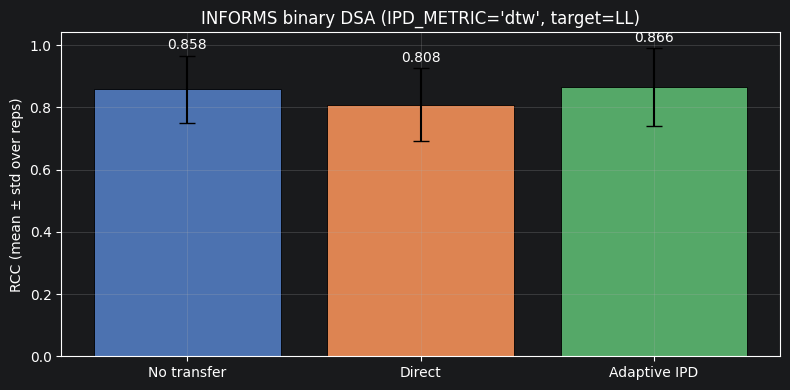

,condition,mean_rcc,std_rcc
0,No transfer,0.858333,0.107787
1,Direct,0.808333,0.117349
2,Adaptive IPD,0.865833,0.125759


Per-rep lists: {'no_transfer': [0.7708333333333334, 0.9666666666666667, 1.0, 0.8291666666666667, 0.725], 'direct_transfer': [0.775, 0.7625, 1.0, 0.8583333333333333, 0.6458333333333334], 'adaptive_ipd': [0.7875, 0.9875, 1.0, 0.8875, 0.6666666666666666]}


In [6]:
labels_short = ["No transfer", "Direct", "Adaptive IPD"]
keys = ["no_transfer", "direct_transfer", "adaptive_ipd"]
means = [
    float(np.mean(informs_results[k])) if informs_results[k] else 0.0 for k in keys
]
stds = [float(np.std(informs_results[k])) if informs_results[k] else 0.0 for k in keys]
xpos = np.arange(len(keys))

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(
    xpos,
    means,
    yerr=stds,
    capsize=6,
    color=["#4c72b0", "#dd8452", "#55a868"],
    edgecolor="black",
    linewidth=0.6,
)
ax.set_xticks(xpos)
ax.set_xticklabels(labels_short)
ax.set_ylabel("RCC (mean ± std over reps)")
ax.set_title(f"INFORMS binary DSA (IPD_METRIC={IPD_METRIC!r}, target={TARGET_UNIT})")
for i, (m, s) in enumerate(zip(means, stds)):
    ax.text(i, m + s + 0.02, f"{m:.3f}", ha="center", fontsize=10)
plt.tight_layout()
plt.show()

df_informs = pd.DataFrame(
    {"condition": labels_short, "mean_rcc": means, "std_rcc": stds}
)
display(df_informs)
print("Per-rep lists:", {k: informs_results[k] for k in keys if informs_results[k]})


### 1.2 Domain IPD heatmap (paired validation segments)

**Figures:** Mean IPD between sensor domains on the shared validation indices (paired by `sample_id`).


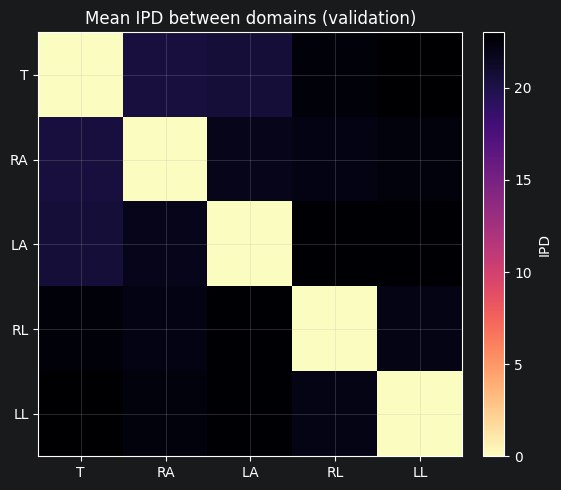

,T,RA,LA,RL,LL
T,0.000,20.370,20.641,22.620,23.014
RA,20.370,0.000,21.909,22.203,22.438
LA,20.641,21.909,0.000,22.912,22.883
RL,22.620,22.203,22.912,0.000,22.093
LL,23.014,22.438,22.883,22.093,0.000


In [7]:
ipd_mat = ipd_similarity_matrix(probe, bundles, ALL_UNITS, val_idx)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(ipd_mat, cmap="magma_r")
ax.set_xticks(range(len(ALL_UNITS)))
ax.set_yticks(range(len(ALL_UNITS)))
ax.set_xticklabels(ALL_UNITS)
ax.set_yticklabels(ALL_UNITS)
ax.set_title("Mean IPD between domains (validation)")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="IPD")
plt.tight_layout()
plt.show()

display(
    pd.DataFrame(ipd_mat, index=list(ALL_UNITS), columns=list(ALL_UNITS)).round(3)
)


### 1.3 Multiclass DSA in PyHealth (19-class accuracy)

**Experiment:** Same transfer protocols as above—**no pretraining**, **direct sequential pretraining** on sources, and **IPD-ranked adaptive pretraining**—evaluated on the standard **19-class** activity labels. This uses the shared `run_experiment` path and the global epoch budget from §0.


In [8]:
main_experiments = [
    TrainConfig("no_transfer", [], False),
    TrainConfig("direct_transfer", canonical_source_order, use_adaptive_lr=False),
    TrainConfig("adaptive_ipd_ranked", ranked_sources, use_adaptive_lr=True),
]

results_main: Dict[str, float] = {}
for cfg in main_experiments:
    print("===", cfg.name, "===")
    results_main[cfg.name] = run_experiment(cfg)
    print("test accuracy:", results_main[cfg.name])


=== no_transfer ===
AdaptiveTransferModel(
  (encoder): LSTM(9, 64, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (classifier): Linear(in_features=64, out_features=19, bias=True)
)
Metrics: ['accuracy']
Device: mps

Training:
Batch size: 64
Optimizer: <class 'torch.optim.adam.Adam'>
Optimizer params: {'lr': 0.001}
Weight decay: 0.0
Max grad norm: None
Val dataloader: <torch.utils.data.dataloader.DataLoader object at 0x14dc76f50>
Monitor: accuracy
Monitor criterion: max
Epochs: 16
Patience: None



Epoch 0 / 16: 100%|██████████| 72/72 [00:01<00:00, 59.20it/s]

--- Train epoch-0, step-72 ---
loss: 2.8936



Evaluation: 100%|██████████| 36/36 [00:00<00:00, 158.76it/s]

--- Eval epoch-0, step-72 ---
accuracy: 0.1333
loss: 2.7617
New best accuracy score (0.1333) at epoch-0, step-72



...

--- Train epoch-7, step-576 ---
loss: 2.1264



Evaluation: 100%|██████████| 36/36 [00:00<00:00, 160.50it/s]

--- Eval epoch-7, step-576 ---
accuracy: 0.2741
loss: 2.1914
New best accuracy score (0.2741) at epoch-7, step-576
AdaptiveTransferModel(
  (encoder): LSTM(9, 64, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (classifier): Linear(in_features=64, out_features=19, bias=True)
)
Metrics: ['accuracy']
Device: mps




Evaluation: 100%|██████████| 36/36 [00:00<00:00, 223.42it/s]

test accuracy: 0.23464912280701755


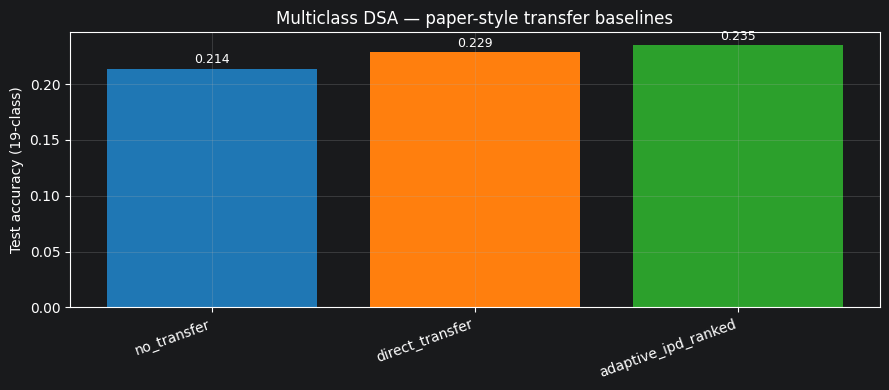

,setting,test_accuracy
0,no_transfer,0.2136
1,direct_transfer,0.2285
2,adaptive_ipd_ranked,0.2346


In [9]:
fig, ax = plt.subplots(figsize=(9, 4))
names = list(results_main.keys())
accs = [results_main[k] for k in names]
xpos = np.arange(len(names))
cmap = plt.get_cmap("tab10")
ax.bar(xpos, accs, color=[cmap(i % 10) for i in range(len(names))])
ax.set_xticks(xpos)
ax.set_ylabel("Test accuracy (19-class)")
ax.set_title("Multiclass DSA — paper-style transfer baselines")
ax.set_xticklabels(names, rotation=20, ha="right")
for i, v in enumerate(accs):
    ax.text(i, v + 0.005, f"{v:.3f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

display(
    pd.DataFrame(
        {"setting": names, "test_accuracy": [round(v, 4) for v in accs]}
    )
)


## 2) Our ablations (proposal plan)

Each subsection keeps the **same** `run_experiment` entry point and changes **one** factor relative to the adaptive IPD baseline in `results_main`.


### 2.1 Unpaired relevance — random source order (H1)

**Experiment:** Identical pipeline to adaptive transfer, but **shuffle** the source pretraining order (breaks correspondence between IPD ranking and physiology-informed pairing).


In [10]:
cfg_rand = TrainConfig(
    "ablation_random_source_order",
    random_order,
    use_adaptive_lr=True,
)
acc_random_order = run_experiment(cfg_rand)
ablation_h1 = {
    "adaptive_ipd_ranked": results_main["adaptive_ipd_ranked"],
    "random_source_order": acc_random_order,
}
print(ablation_h1)


AdaptiveTransferModel(
  (encoder): LSTM(9, 64, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (classifier): Linear(in_features=64, out_features=19, bias=True)
)
Metrics: ['accuracy']
Device: mps

Training:
Batch size: 64
Optimizer: <class 'torch.optim.adam.Adam'>
Optimizer params: {'lr': 4.526226395053778e-05}
Weight decay: 0.0
Max grad norm: None
Val dataloader: <torch.utils.data.dataloader.DataLoader object at 0x14dc76f50>
Monitor: accuracy
Monitor criterion: max
Epochs: 2
Patience: None



Epoch 0 / 2: 100%|██████████| 72/72 [00:01<00:00, 62.84it/s] 

--- Train epoch-0, step-72 ---
loss: 2.9479



Evaluation: 100%|██████████| 36/36 [00:00<00:00, 161.40it/s]

--- Eval epoch-0, step-72 ---
accuracy: 0.0439
loss: 2.9466
New best accuracy score (0.0439) at epoch-0, step-72



...

--- Train epoch-7, step-576 ---
loss: 2.0179



Evaluation: 100%|██████████| 36/36 [00:00<00:00, 168.38it/s]

--- Eval epoch-7, step-576 ---
accuracy: 0.2807
loss: 2.1333
AdaptiveTransferModel(
  (encoder): LSTM(9, 64, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (classifier): Linear(in_features=64, out_features=19, bias=True)
)
Metrics: ['accuracy']
Device: mps




Evaluation: 100%|██████████| 36/36 [00:00<00:00, 223.89it/s]

{'adaptive_ipd_ranked': 0.23464912280701755, 'random_source_order': 0.2469298245614035}


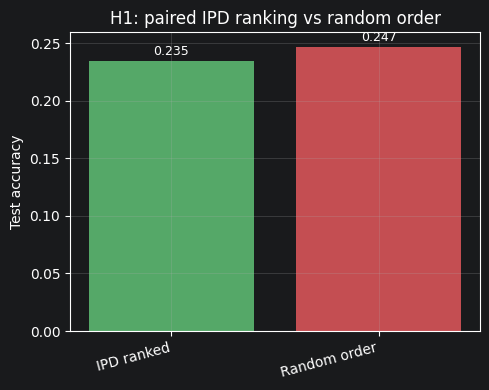

,test_accuracy
adaptive_ipd_ranked,0.234649
random_source_order,0.246930


In [11]:
fig, ax = plt.subplots(figsize=(5, 4))
labels = list(ablation_h1.keys())
vals = [ablation_h1[k] for k in labels]
ax.bar(range(len(labels)), vals, color=["#55a868", "#c44e52"])
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(["IPD ranked", "Random order"], rotation=15, ha="right")
ax.set_ylabel("Test accuracy")
ax.set_title("H1: paired IPD ranking vs random order")
for i, v in enumerate(vals):
    ax.text(i, v + 0.005, f"{v:.3f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

display(pd.DataFrame([ablation_h1]).T.rename(columns={0: "test_accuracy"}))


### 2.2 Fixed learning rates on sources (H2)

**Experiment:** Keep the **IPD-derived source order**, but disable similarity-scaled learning rates (`use_adaptive_lr=False`) so every source phase uses the same `base_lr`.


In [12]:
cfg_fixed = TrainConfig(
    "ablation_fixed_lr_ipd_order",
    ranked_sources,
    use_adaptive_lr=False,
)
acc_fixed_lr = run_experiment(cfg_fixed)
ablation_h2 = {
    "adaptive_ipd_ranked": results_main["adaptive_ipd_ranked"],
    "fixed_lr_ipd_order": acc_fixed_lr,
}
print(ablation_h2)


AdaptiveTransferModel(
  (encoder): LSTM(9, 64, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (classifier): Linear(in_features=64, out_features=19, bias=True)
)
Metrics: ['accuracy']
Device: mps

Training:
Batch size: 64
Optimizer: <class 'torch.optim.adam.Adam'>
Optimizer params: {'lr': 0.001}
Weight decay: 0.0
Max grad norm: None
Val dataloader: <torch.utils.data.dataloader.DataLoader object at 0x1182a8650>
Monitor: accuracy
Monitor criterion: max
Epochs: 2
Patience: None



Epoch 0 / 2: 100%|██████████| 72/72 [00:01<00:00, 59.98it/s] 

--- Train epoch-0, step-72 ---
loss: 2.8902



Evaluation: 100%|██████████| 36/36 [00:00<00:00, 163.82it/s]

--- Eval epoch-0, step-72 ---
accuracy: 0.1035
loss: 2.7785
New best accuracy score (0.1035) at epoch-0, step-72



...

--- Train epoch-7, step-576 ---
loss: 2.0539



Evaluation: 100%|██████████| 36/36 [00:00<00:00, 160.59it/s]

--- Eval epoch-7, step-576 ---
accuracy: 0.2250
loss: 2.2132
New best accuracy score (0.2250) at epoch-7, step-576
AdaptiveTransferModel(
  (encoder): LSTM(9, 64, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (classifier): Linear(in_features=64, out_features=19, bias=True)
)
Metrics: ['accuracy']
Device: mps




Evaluation: 100%|██████████| 36/36 [00:00<00:00, 205.43it/s]

{'adaptive_ipd_ranked': 0.23464912280701755, 'fixed_lr_ipd_order': 0.25526315789473686}


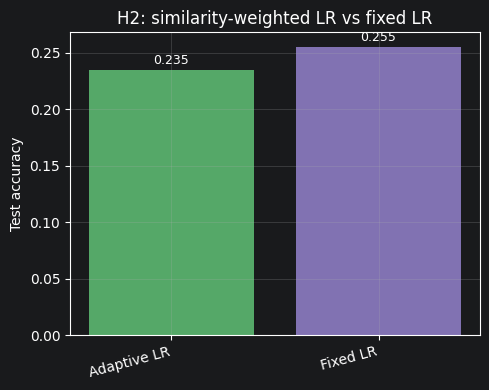

,test_accuracy
adaptive_ipd_ranked,0.234649
fixed_lr_ipd_order,0.255263


In [13]:
fig, ax = plt.subplots(figsize=(5, 4))
labels = list(ablation_h2.keys())
vals = [ablation_h2[k] for k in labels]
ax.bar(range(len(labels)), vals, color=["#55a868", "#8172b2"])
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(["Adaptive LR", "Fixed LR"], rotation=15, ha="right")
ax.set_ylabel("Test accuracy")
ax.set_title("H2: similarity-weighted LR vs fixed LR")
for i, v in enumerate(vals):
    ax.text(i, v + 0.005, f"{v:.3f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

display(pd.DataFrame([ablation_h2]).T.rename(columns={0: "test_accuracy"}))


### 2.3 Smooth bootstrap ablation for DTW–IPD (KDE on/off)

**Experiment:** Recompute source rankings using **plain mean** paired DTW distances (`ipd_use_paper_kde=False`) instead of the **KernelDensity** draw-average used in the reference implementation, then rerun adaptive transfer with that ranking.

*(With embedding IPD, this toggle is ignored; compare KDE vs mean under the default DTW IPD setting.)*


In [14]:
ranked_plain, _ = ranked_sources_ipd(probe, bundles, val_idx, use_paper_kde=False)
cfg_kde = TrainConfig(
    "ablation_ipd_no_kde",
    ranked_plain,
    use_adaptive_lr=True,
    ipd_use_paper_kde=False,
)
acc_no_kde = run_experiment(cfg_kde)
ablation_h3_kde = {
    "adaptive_ipd_ranked_kde": results_main["adaptive_ipd_ranked"],
    "adaptive_plain_mean_ipd": acc_no_kde,
}
print("Ranked (KDE):", ranked_sources)
print("Ranked (plain mean):", ranked_plain)
print(ablation_h3_kde)


AdaptiveTransferModel(
  (encoder): LSTM(9, 64, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (classifier): Linear(in_features=64, out_features=19, bias=True)
)
Metrics: ['accuracy']
Device: mps

Training:
Batch size: 64
Optimizer: <class 'torch.optim.adam.Adam'>
Optimizer params: {'lr': 4.707638543761449e-05}
Weight decay: 0.0
Max grad norm: None
Val dataloader: <torch.utils.data.dataloader.DataLoader object at 0x150ffdd50>
Monitor: accuracy
Monitor criterion: max
Epochs: 2
Patience: None



Epoch 0 / 2: 100%|██████████| 72/72 [00:01<00:00, 61.75it/s]

--- Train epoch-0, step-72 ---
loss: 2.9468



Evaluation: 100%|██████████| 36/36 [00:00<00:00, 163.24it/s]

--- Eval epoch-0, step-72 ---
accuracy: 0.0548
loss: 2.9481
New best accuracy score (0.0548) at epoch-0, step-72



...

--- Train epoch-7, step-576 ---
loss: 2.4935



Evaluation: 100%|██████████| 36/36 [00:00<00:00, 162.19it/s]

--- Eval epoch-7, step-576 ---
accuracy: 0.1390
loss: 2.5841
AdaptiveTransferModel(
  (encoder): LSTM(9, 64, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (classifier): Linear(in_features=64, out_features=19, bias=True)
)
Metrics: ['accuracy']
Device: mps




Evaluation: 100%|██████████| 36/36 [00:00<00:00, 223.81it/s]

Ranked (KDE): ['RL', 'RA', 'LA', 'T']
Ranked (plain mean): ['RL', 'LA', 'RA', 'T']
{'adaptive_ipd_ranked_kde': 0.23464912280701755, 'adaptive_plain_mean_ipd': 0.1513157894736842}


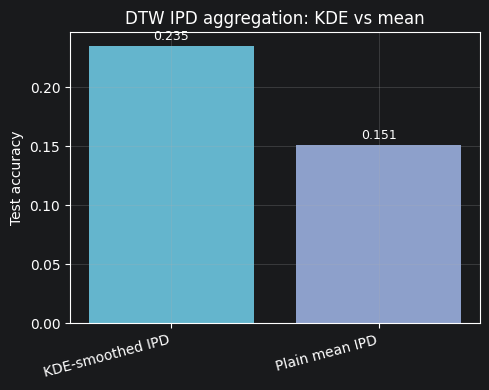

,test_accuracy
adaptive_ipd_ranked_kde,0.234649
adaptive_plain_mean_ipd,0.151316


In [15]:
fig, ax = plt.subplots(figsize=(5, 4))
labels = ["KDE-smoothed IPD", "Plain mean IPD"]
vals = [ablation_h3_kde["adaptive_ipd_ranked_kde"], ablation_h3_kde["adaptive_plain_mean_ipd"]]
ax.bar(range(2), vals, color=["#64b5cd", "#8da0cb"])
ax.set_xticks(range(2))
ax.set_xticklabels(labels, rotation=15, ha="right")
ax.set_ylabel("Test accuracy")
ax.set_title("DTW IPD aggregation: KDE vs mean")
for i, v in enumerate(vals):
    ax.text(i, v + 0.005, f"{v:.3f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

display(pd.DataFrame([ablation_h3_kde]).T.rename(columns={0: "test_accuracy"}))


### 2.4 Test-time Gaussian noise (H3-style robustness)

**Experiment:** Retrain **no-transfer** and **adaptive IPD** models from scratch, then measure multiclass accuracy while injecting i.i.d. Gaussian noise into test inputs.


In [16]:
target_test = bundles[TARGET_UNIT].test
_, _, test_loader_noise = make_loaders(
    bundles[TARGET_UNIT].train,
    bundles[TARGET_UNIT].val,
    target_test,
)
noise_levels = [0.0, 0.05, 0.1, 0.2, 0.3]


def train_model_for_noise(mode: str) -> AdaptiveTransferModel:
    target_train = bundles[TARGET_UNIT].train
    target_val = bundles[TARGET_UNIT].val
    tr_l, va_l, _ = make_loaders(target_train, target_val, target_test)
    model = AdaptiveTransferModel(
        dataset=target_train,
        feature_key="signal",
        hidden_dim=HIDDEN_DIM,
        num_layers=NUM_LAYERS,
        dropout=DROPOUT,
        backbone="lstm",
    ).to(DEVICE)
    if mode == "no_transfer":
        total_epochs = EPOCHS_PRETRAIN_PER_SOURCE * len(SOURCE_UNITS) + EPOCHS_FINETUNE
        train_with_trainer(model, tr_l, va_l, epochs=total_epochs, lr=1e-3)
        return model
    for src in ranked_sources:
        sim = 1.0 / (
            mean_ipd_between(
                probe, bundles[src].full, bundles[TARGET_UNIT].full, val_idx
            )
            + 1e-8
        )
        lr = model.get_adaptive_lr(1e-3, sim)
        src_train = bundles[src].train
        s_tr, s_va, _ = make_loaders(src_train, bundles[src].val, bundles[src].test)
        train_with_trainer(model, s_tr, s_va, epochs=EPOCHS_PRETRAIN_PER_SOURCE, lr=lr)
    train_with_trainer(model, tr_l, va_l, epochs=EPOCHS_FINETUNE, lr=1e-3)
    return model


print("Training fresh models for noise sweep …")
m0 = train_model_for_noise("no_transfer")
acc_noise_0 = accuracy_under_noise(m0, test_loader_noise, noise_levels)
m1 = train_model_for_noise("adaptive_ipd")
acc_noise_1 = accuracy_under_noise(m1, test_loader_noise, noise_levels)


Training fresh models for noise sweep …
AdaptiveTransferModel(
  (encoder): LSTM(9, 64, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (classifier): Linear(in_features=64, out_features=19, bias=True)
)
Metrics: ['accuracy']
Device: mps

Training:
Batch size: 64
Optimizer: <class 'torch.optim.adam.Adam'>
Optimizer params: {'lr': 0.001}
Weight decay: 0.0
Max grad norm: None
Val dataloader: <torch.utils.data.dataloader.DataLoader object at 0x151090d50>
Monitor: accuracy
Monitor criterion: max
Epochs: 16
Patience: None



Epoch 0 / 16: 100%|██████████| 72/72 [00:01<00:00, 52.89it/s]

--- Train epoch-0, step-72 ---
loss: 2.9074



Evaluation: 100%|██████████| 36/36 [00:00<00:00, 159.61it/s]

--- Eval epoch-0, step-72 ---
accuracy: 0.1566
loss: 2.8222
New best accuracy score (0.1566) at epoch-0, step-72



...

--- Eval epoch-6, step-504 ---
accuracy: 0.3184
loss: 1.9988
New best accuracy score (0.3184) at epoch-6, step-504




Epoch 7 / 8: 100%|██████████| 72/72 [00:01<00:00, 61.53it/s] 

--- Train epoch-7, step-576 ---
loss: 1.9467



Evaluation: 100%|██████████| 36/36 [00:00<00:00, 161.20it/s]

--- Eval epoch-7, step-576 ---
accuracy: 0.3175
loss: 2.0618


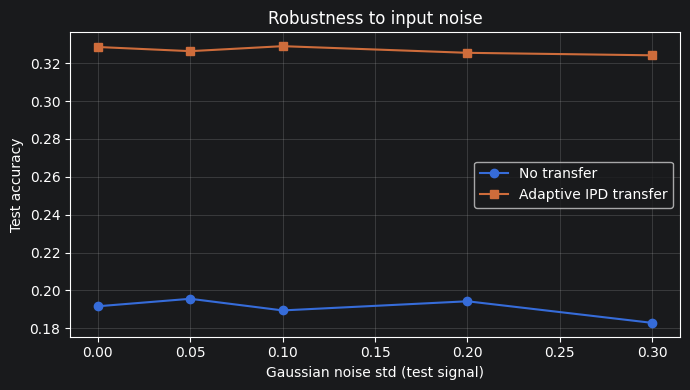

,noise_std,no_transfer,adaptive_ipd
0,0.00,0.191667,0.328509
1,0.05,0.195614,0.326316
2,0.10,0.189474,0.328947
3,0.20,0.194298,0.325439
4,0.30,0.182895,0.324123


In [17]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(noise_levels, acc_noise_0, marker="o", label="No transfer")
ax.plot(noise_levels, acc_noise_1, marker="s", label="Adaptive IPD transfer")
ax.set_xlabel("Gaussian noise std (test signal)")
ax.set_ylabel("Test accuracy")
ax.set_title("Robustness to input noise")
ax.legend()
plt.tight_layout()
plt.show()

display(
    pd.DataFrame(
        {"noise_std": noise_levels, "no_transfer": acc_noise_0, "adaptive_ipd": acc_noise_1}
    )
)


### 2.5 Optional flag grid on `AdaptiveTransferModel` (embedding IPD only)

**Experiment:** When `IPD_METRIC == "embedding"`, toggling `use_kde_smoothing` / `use_similarity_weighting` / string `distance_fn` on the **classifier** model changes both IPD-based LR scaling and internal smoothing. With DTW–IPD these flags barely affect ranking; enable `RUN_FULL_ABLATION_GRID` to run the extra settings.


In [18]:
results_flag_grid: Dict[str, float] = {}
if RUN_FULL_ABLATION_GRID and IPD_METRIC == "embedding":
    grid = [
        ("adaptive_default", "euclidean", True, True),
        ("no_kde_smoothing", "euclidean", True, False),
        ("no_similarity_lr_model", "euclidean", False, True),
        ("distance_cosine", "cosine", True, True),
        ("distance_manhattan", "manhattan", True, True),
    ]
    for name, dist, sim_w, kde in grid:
        cfg = TrainConfig(
            name=name,
            pretrain_order=ranked_sources,
            use_adaptive_lr=sim_w,
            model_distance=dist,
            use_kde_smoothing=kde,
            use_similarity_weighting=sim_w,
        )
        print("=== flag grid:", name, "===")
        results_flag_grid[name] = run_experiment(cfg)
elif not RUN_FULL_ABLATION_GRID:
    print("Set RUN_FULL_ABLATION_GRID = True (and preferably IPD_METRIC='embedding') to run §2.5.")
else:
    print("Skip §2.5: requires IPD_METRIC='embedding'.")


Set RUN_FULL_ABLATION_GRID = True (and preferably IPD_METRIC='embedding') to run §2.5.


In [19]:
if results_flag_grid:
    fig, ax = plt.subplots(figsize=(10, 4))
    keys = list(results_flag_grid.keys())
    vals = [results_flag_grid[k] for k in keys]
    ax.bar(np.arange(len(keys)), vals, color="steelblue")
    ax.set_xticks(np.arange(len(keys)))
    ax.set_ylabel("Test accuracy")
    ax.set_title("Embedding-IPD flag ablations")
    ax.set_xticklabels(keys, rotation=25, ha="right")
    plt.tight_layout()
    plt.show()
    display(pd.DataFrame({"setting": keys, "test_accuracy": vals}))
else:
    print("No flag-grid results to plot.")


No flag-grid results to plot.


## 3) Our extensions — embedding IPD distance functions

**Setup:** The PyHealth `AdaptiveTransferModel` accepts `distance_fn` as any `torch` callable on paired embeddings. To stress-test that hook **and** keep DTW-based domain statistics untouched, this section temporarily sets `IPD_METRIC = "embedding"`, trains a **fresh probe** for each distance, recomputes the source order, and calls the same `run_experiment` routine (`model_distance="euclidean"` for the classifier; IPD magnitudes come from `ipd_probe`).

**Distances:** Euclidean (string), Minkowski order 3 (`F.pairwise_distance`), and Kulczynski’s metric via `scipy.spatial.distance.kulczynski1` on per-sample median-binarized embeddings.


### 3.1 Probe-distance sensitivity experiment


In [22]:
_saved_ipd_metric = IPD_METRIC
IPD_METRIC = "embedding"

extension_results: Dict[str, float] = {}
probe_train_loader, probe_val_loader, _ = make_loaders(
    bundles[TARGET_UNIT].train,
    bundles[TARGET_UNIT].val,
    bundles[TARGET_UNIT].test,
)

distance_specs: List[Tuple[str, Union[str, Callable[[torch.Tensor, torch.Tensor], torch.Tensor]]]] = [
    ("euclidean", "euclidean"),
    ("minkowski_p3", lambda x, y: F.pairwise_distance(x, y, p=3)),
    ("kulczynski1_median_bin", kulczynski_pairwise),
]

for label, dist in distance_specs:
    probe_ext = AdaptiveTransferModel(
        dataset=bundles[TARGET_UNIT].train,
        feature_key="signal",
        hidden_dim=HIDDEN_DIM,
        num_layers=NUM_LAYERS,
        dropout=DROPOUT,
        backbone="lstm",
        distance_fn=dist,
        use_similarity_weighting=True,
        use_kde_smoothing=True,
    ).to(DEVICE)
    train_with_trainer(
        probe_ext,
        probe_train_loader,
        probe_val_loader,
        epochs=EPOCHS_PROBE,
        lr=1e-3,
    )
    rank_ext, _ = ranked_sources_ipd(probe_ext, bundles, val_idx)
    cfg = TrainConfig(
        name=f"extension_{label}",
        pretrain_order=rank_ext,
        use_adaptive_lr=True,
    )
    print(f"=== extension {label} | rank {rank_ext} ===")
    extension_results[label] = run_experiment(cfg, ipd_probe=probe_ext)

IPD_METRIC = _saved_ipd_metric
print("Restored IPD_METRIC to", IPD_METRIC)


AdaptiveTransferModel(
  (encoder): LSTM(9, 64, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (classifier): Linear(in_features=64, out_features=19, bias=True)
)
Metrics: ['accuracy']
Device: mps

Training:
Batch size: 64
Optimizer: <class 'torch.optim.adam.Adam'>
Optimizer params: {'lr': 0.001}
Weight decay: 0.0
Max grad norm: None
Val dataloader: <torch.utils.data.dataloader.DataLoader object at 0x14dc75f50>
Monitor: accuracy
Monitor criterion: max
Epochs: 2
Patience: None



Epoch 0 / 2: 100%|██████████| 72/72 [00:01<00:00, 60.78it/s]

--- Train epoch-0, step-72 ---
loss: 2.8884



Evaluation: 100%|██████████| 36/36 [00:00<00:00, 134.29it/s]

--- Eval epoch-0, step-72 ---
accuracy: 0.1232
loss: 2.7521
New best accuracy score (0.1232) at epoch-0, step-72



...

--- Train epoch-7, step-576 ---
loss: 2.6413



Evaluation: 100%|██████████| 36/36 [00:00<00:00, 113.56it/s]

--- Eval epoch-7, step-576 ---
accuracy: 0.1439
loss: 2.6731
AdaptiveTransferModel(
  (encoder): LSTM(9, 64, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (classifier): Linear(in_features=64, out_features=19, bias=True)
)
Metrics: ['accuracy']
Device: mps




Evaluation: 100%|██████████| 36/36 [00:00<00:00, 94.90it/s]

Restored IPD_METRIC to embedding


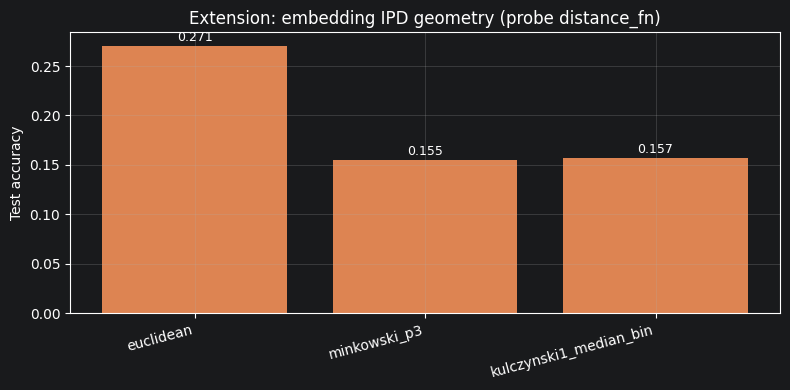

,distance,test_accuracy
0,euclidean,0.2706
1,minkowski_p3,0.1553
2,kulczynski1_median_bin,0.1570


In [23]:
fig, ax = plt.subplots(figsize=(8, 4))
keys = list(extension_results.keys())
vals = [extension_results[k] for k in keys]
ax.bar(np.arange(len(keys)), vals, color="#dd8452")
ax.set_xticks(np.arange(len(keys)))
ax.set_ylabel("Test accuracy")
ax.set_title("Extension: embedding IPD geometry (probe distance_fn)")
ax.set_xticklabels(keys, rotation=15, ha="right")
for i, v in enumerate(vals):
    ax.text(i, v + 0.005, f"{v:.3f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

display(pd.DataFrame({"distance": keys, "test_accuracy": [round(v, 4) for v in vals]}))


## References

- Barshan & Altun (2014). Daily and Sports Activities. UCI ML Repository.
- Zhang et al., *Daily Physical Activity Monitoring: Adaptive Learning from Multi-Source Motion Sensor Data*.
